## 11.11节练习参考答案

## 环境准备

In [ ]:
import os, sys
os.environ["TILE_FWK_DEVICE_ID"] = "0"
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))
# 本 notebook 位于 answers/ 子目录下，数据缓存在 ../data（与主 notebook 共享），
# 切到章节根目录避免重新慢速下载数据集。
if os.path.isdir("../src"):
    os.chdir("..")

# 固定 PyPTO 编译缓存目录（与 11.11/11.08 主 notebook 共用 ../ptile_cache）：
# 内核/Jupyter 重启后无需从零重新编译算子。
# PTO_TILE_LIB_CODE_PATH 目录还必须包含 include/pto（pto-isa 头文件），
# 否则算子编译时报 PTO_ISA_NOT_FOUND；用软链指向 CANN 自带的头文件即可。
os.environ["PTO_TILE_LIB_CODE_PATH"] = os.path.abspath("../ptile_cache")
_pto_lib = os.environ["PTO_TILE_LIB_CODE_PATH"]
os.makedirs(os.path.join(_pto_lib, "include"), exist_ok=True)
_pto_isa_link = os.path.join(_pto_lib, "include", "pto")
if not os.path.exists(_pto_isa_link):
    import glob
    _isa_candidates = glob.glob(os.path.expanduser(
        "~/Ascend/cann-*/aarch64-linux/include/pto"))
    if _isa_candidates:
        os.symlink(os.path.abspath(_isa_candidates[0]), _pto_isa_link)
    else:
        raise RuntimeError("未找到 pto-isa 头文件目录（~/Ascend/cann-*/aarch64-linux/include/pto）")

%matplotlib inline
import pypto
import numpy as np
import matplotlib.pyplot as plt
import torch
import torch_npu
import torchvision
from torchvision import transforms
import torch.nn as nn
import torch.nn.functional as F
import math
from torch.optim import lr_scheduler

from src.utils import *
from src.pto_layers import PyPTOLinear, PyPTOReLU
from src.PyPTOConv2DModule import PyPTOConv2d
from src.PyPTOPoolModule import PyPTOMaxPool2d

本节的解答思路参考了 [《动手学深度学习》习题解答](https://datawhalechina.github.io/d2l-ai-solutions-manual/#/ch11/ch11)，并在此基础上补充了 PyPTO 的实现。

In [2]:
def accuracy(y_hat, y):
    if len(y_hat.shape) > 1 and y_hat.shape[1] > 1:
        y_hat = y_hat.argmax(axis=1)
    cmp = y_hat.type(y.dtype) == y
    return float(cmp.type(y.dtype).sum())

def try_gpu(i=0):
    if torch.npu.is_available():
        return torch.device(f"npu:{i}")
    return torch.device("cpu")

# 数据加载直接使用 src.utils 的 load_data_fashion_mnist（drop_last=True）：
# 丢弃不满的尾批，使训练/评估全程只有 bs=256 一种 batch 形状，
# 避免 PyPTO kernel 因尾批形状（96/16）触发新一轮漫长的 JIT 编译。

def evaluate_accuracy_gpu(net, data_iter, device=None):
    if isinstance(net, nn.Module):
        net.eval()
        if not device:
            device = next(iter(net.parameters())).device
    metric = Accumulator(2)
    with torch.no_grad():
        for X, y in data_iter:
            if isinstance(X, list):
                X = [x.to(device) for x in X]
            else:
                X = X.to(device)
            y = y.to(device)
            metric.add(accuracy(net(X), y), y.numel())
    return metric[0] / metric[1]

### 练习11.11.1
试验给定固定学习率的优化行为。这种情况下可以获得的最佳模型是什么？

**解答：**

train loss 0.173, train acc 0.933, test acc 0.890


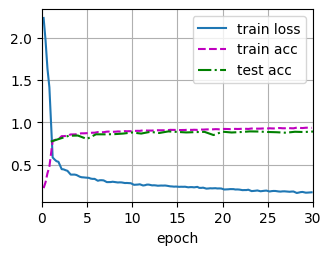

In [4]:
def net_fn():
    model = nn.Sequential(
        nn.Conv2d(1, 6, kernel_size=5, padding=2), nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Conv2d(6, 16, kernel_size=5), nn.ReLU(),
        nn.MaxPool2d(kernel_size=2, stride=2),
        nn.Flatten(),
        nn.Linear(16 * 5 * 5, 120), nn.ReLU(),
        nn.Linear(120, 84), nn.ReLU(),
        nn.Linear(84, 10))

    return model

loss = nn.CrossEntropyLoss()
device = try_gpu()

batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size=batch_size)

# 代码几乎与train_ch6定义在卷积神经网络一章LeNet一节中的相同
def train(net, train_iter, test_iter, num_epochs, loss, trainer, device,
          scheduler=None):
    net.to(device)
    animator = Animator(xlabel='epoch', xlim=[0, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])

    for epoch in range(num_epochs):
        metric = Accumulator(3)  # train_loss,train_acc,num_examples
        for i, (X, y) in enumerate(train_iter):
            net.train()
            trainer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            trainer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], accuracy(y_hat, y), X.shape[0])
            train_loss = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % 50 == 0:
                animator.add(epoch + i / len(train_iter),
                             (train_loss, train_acc, None))

        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch+1, (None, None, test_acc))

        if scheduler:
            if scheduler.__module__ == lr_scheduler.__name__:
                # UsingPyTorchIn-Builtscheduler
                scheduler.step()
            else:
                # Usingcustomdefinedscheduler
                for param_group in trainer.param_groups:
                    param_group['lr'] = scheduler(epoch)

    print(f'train loss {train_loss:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')

lr, num_epochs = 0.3, 30
net = net_fn()
trainer = torch.optim.SGD(net.parameters(), lr=lr)
train(net, train_iter, test_iter, num_epochs, loss, trainer, device)

In [5]:
lr = 0.1
trainer.param_groups[0]["lr"] = lr
print(f'learning rate is now {trainer.param_groups[0]["lr"]:.2f}')

learning rate is now 0.10


In [6]:
class SquareRootScheduler:
    def __init__(self, lr=0.1):
        self.lr = lr

    def __call__(self, num_update):
        return self.lr * pow(num_update + 1.0, -0.5)

class CosineScheduler:
    def __init__(self, max_update, base_lr=0.01, final_lr=0,
               warmup_steps=0, warmup_begin_lr=0):
        self.base_lr_orig = base_lr
        self.max_update = max_update
        self.final_lr = final_lr
        self.warmup_steps = warmup_steps
        self.warmup_begin_lr = warmup_begin_lr
        self.max_steps = self.max_update - self.warmup_steps

    def get_warmup_lr(self, epoch):
        increase = (self.base_lr_orig - self.warmup_begin_lr) \
                       * float(epoch) / float(self.warmup_steps)
        return self.warmup_begin_lr + increase

    def __call__(self, epoch):
        if epoch < self.warmup_steps:
            return self.get_warmup_lr(epoch)
        if epoch <= self.max_update:
            self.base_lr = self.final_lr + (
                self.base_lr_orig - self.final_lr) * (1 + math.cos(
                math.pi * (epoch - self.warmup_steps) / self.max_steps)) / 2
        return self.base_lr

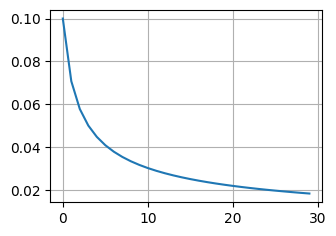

In [7]:
scheduler = CosineScheduler(max_update=20, base_lr=0.3, final_lr=0.01)
plot(torch.arange(num_epochs), [scheduler(t) for t in range(num_epochs)])

scheduler = SquareRootScheduler(lr=0.1)
plot(torch.arange(num_epochs), [scheduler(t) for t in range(num_epochs)])

train loss 0.256, train acc 0.907, test acc 0.879


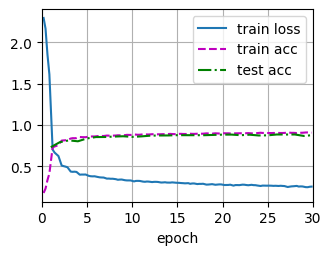

In [8]:
net = net_fn()
trainer = torch.optim.SGD(net.parameters(), lr)
train(net, train_iter, test_iter, num_epochs, loss, trainer, device, scheduler)

**PyPTO 版**

warm up bs=256: 17.5s
train loss 0.148, train acc 0.943, test acc 0.893


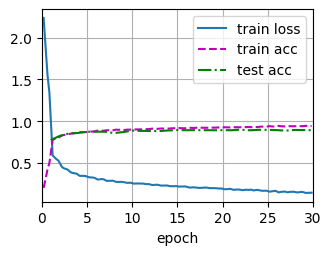

In [3]:
def net_fn():
    model = nn.Sequential(
        PyPTOConv2d(1, 6, kernel_size=5, padding=2), PyPTOReLU(),
        PyPTOMaxPool2d(kernel_size=2, stride=2),
        PyPTOConv2d(6, 16, kernel_size=5), PyPTOReLU(),
        PyPTOMaxPool2d(kernel_size=2, stride=2),
        nn.Flatten(),
        PyPTOLinear(16 * 5 * 5, 120), PyPTOReLU(),
        PyPTOLinear(120, 84), PyPTOReLU(),
        PyPTOLinear(84, 10))

    return model

loss = nn.CrossEntropyLoss()
device = try_gpu()

batch_size = 256
train_iter, test_iter = load_data_fashion_mnist(batch_size=batch_size)

# 代码几乎与train_ch6定义在卷积神经网络一章LeNet一节中的相同
def train(net, train_iter, test_iter, num_epochs, loss, trainer, device,
          scheduler=None):
    net.to(device)
    animator = Animator(xlabel='epoch', xlim=[0, num_epochs],
                            legend=['train loss', 'train acc', 'test acc'])

    for epoch in range(num_epochs):
        metric = Accumulator(3)  # train_loss,train_acc,num_examples
        for i, (X, y) in enumerate(train_iter):
            net.train()
            trainer.zero_grad()
            X, y = X.to(device), y.to(device)
            y_hat = net(X)
            l = loss(y_hat, y)
            l.backward()
            trainer.step()
            with torch.no_grad():
                metric.add(l * X.shape[0], accuracy(y_hat, y), X.shape[0])
            train_loss = metric[0] / metric[2]
            train_acc = metric[1] / metric[2]
            if (i + 1) % 50 == 0:
                animator.add(epoch + i / len(train_iter),
                             (train_loss, train_acc, None))

        test_acc = evaluate_accuracy_gpu(net, test_iter)
        animator.add(epoch+1, (None, None, test_acc))

        if scheduler:
            if scheduler.__module__ == lr_scheduler.__name__:
                # UsingPyTorchIn-Builtscheduler
                scheduler.step()
            else:
                # Usingcustomdefinedscheduler
                for param_group in trainer.param_groups:
                    param_group['lr'] = scheduler(epoch)

    print(f'train loss {train_loss:.3f}, train acc {train_acc:.3f}, '
          f'test acc {test_acc:.3f}')

# PyPTO 自定义算子首次调用时需要 JIT 编译，每种新的 batch 形状耗时约 1~2 分钟，
# 期间 notebook 看似“卡住”（无输出），属正常现象，请耐心等待、切勿中断内核。
# 数据加载已启用 drop_last=True，训练/评估全程只有 bs=256 一种 batch 形状，
# 因此只需预热该形状（前向+反向）即可；配合 ../ptile_cache 编译缓存，
# 重启内核后再次运行时本次预热通常只需数秒：
import time

_net = net_fn().to(device)
t0 = time.time()
X = torch.randn(256, 1, 28, 28, device=device)
y = torch.randint(0, 10, (256,), device=device)
l = loss(_net(X), y)
l.backward()  # 仅触发反向 kernel 编译，不执行 optimizer.step()，权重不变
print(f'warm up bs=256: {time.time() - t0:.1f}s', flush=True)
del _net

lr, num_epochs = 0.3, 30
net = net_fn()
trainer = torch.optim.SGD(net.parameters(), lr=lr)
train(net, train_iter, test_iter, num_epochs, loss, trainer, device)

In [4]:
lr = 0.1
trainer.param_groups[0]["lr"] = lr
print(f'learning rate is now {trainer.param_groups[0]["lr"]:.2f}')

learning rate is now 0.10


In [5]:
class SquareRootScheduler:
    def __init__(self, lr=0.1):
        self.lr = lr

    def __call__(self, num_update):
        return self.lr * pow(num_update + 1.0, -0.5)

class CosineScheduler:
    def __init__(self, max_update, base_lr=0.01, final_lr=0,
               warmup_steps=0, warmup_begin_lr=0):
        self.base_lr_orig = base_lr
        self.max_update = max_update
        self.final_lr = final_lr
        self.warmup_steps = warmup_steps
        self.warmup_begin_lr = warmup_begin_lr
        self.max_steps = self.max_update - self.warmup_steps

    def get_warmup_lr(self, epoch):
        increase = (self.base_lr_orig - self.warmup_begin_lr) \
                       * float(epoch) / float(self.warmup_steps)
        return self.warmup_begin_lr + increase

    def __call__(self, epoch):
        if epoch < self.warmup_steps:
            return self.get_warmup_lr(epoch)
        if epoch <= self.max_update:
            self.base_lr = self.final_lr + (
                self.base_lr_orig - self.final_lr) * (1 + math.cos(
                math.pi * (epoch - self.warmup_steps) / self.max_steps)) / 2
        return self.base_lr

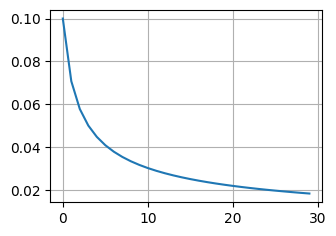

In [6]:
scheduler = CosineScheduler(max_update=20, base_lr=0.3, final_lr=0.01)
plot(torch.arange(num_epochs), [scheduler(t) for t in range(num_epochs)])

scheduler = SquareRootScheduler(lr=0.1)
plot(torch.arange(num_epochs), [scheduler(t) for t in range(num_epochs)])

train loss 0.281, train acc 0.897, test acc 0.885


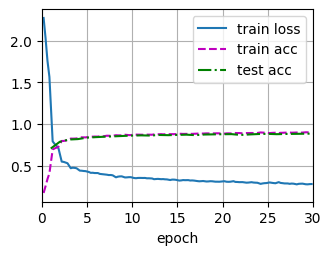

In [7]:
net = net_fn()
trainer = torch.optim.SGD(net.parameters(), lr)
train(net, train_iter, test_iter, num_epochs, loss, trainer, device, scheduler)

### 练习11.11.2
如果改变学习率下降的指数，收敛性会如何改变？在实验中方便起见，使用`PolyScheduler`。

**解答：**

train loss 0.338, train acc 0.876, test acc 0.864


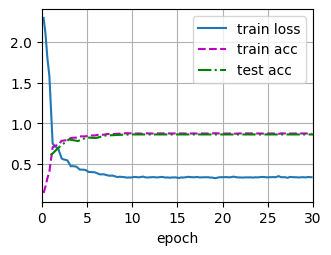

In [9]:
net = net_fn()
trainer = torch.optim.SGD(net.parameters(), lr)
# 定义PolyScheduler并设置参数
scheduler = lr_scheduler.PolynomialLR(trainer, total_iters=10, power=0.9)
train(net, train_iter, test_iter, num_epochs, loss, trainer, device, scheduler)

### 练习11.11.3
将余弦调度器应用于大型计算机视觉问题，例如训练ImageNet数据集。与其他调度器相比，它如何影响性能？

**解答：**

与其他调度器相比，余弦调度器在性能方面有一些独特的影响。

1. **初始学习率设置**：余弦调度器要求设置一个初始学习率。通常情况下，较大的学习率可以加快模型的收敛速度，但同时也可能导致训练过程中的不稳定性。因此，选择一个合适的初始学习率对于获得较好的性能至关重要。

2. **学习率下降**：余弦调度器通过在训练过程中逐渐降低学习率来优化模型的训练。它使用了余弦函数的形式来调整学习率，使其在训练的不同阶段按照一种平滑的方式进行下降。这种方式相对于其他调度器（如固定学习率或按照一定步长进行衰减的调度器）可以更好地平衡模型的收敛速度和稳定性。

3. **阶段划分**：余弦调度器将整个训练过程划分为多个阶段，每个阶段具有不同的学习率。这些阶段的划分可以根据训练数据的大小和复杂性进行调整。通常情况下，初始阶段使用较大的学习率以加快模型的收敛，后续阶段逐渐降低学习率以确保模型更好地拟合数据。

4. **平滑下降**：余弦调度器的学习率下降过程相对平滑，不像其他调度器那样存在突然的学习率变化。这种平滑的下降可以帮助模型避免陷入局部极小值，并且在优化过程中更容易跳出局部极小值并找到全局最优解。

余弦调度器在大型计算机视觉问题中的应用可以通过逐渐降低学习率、平滑下降以及合理的阶段划分来提升性能。它可以帮助模型更好地收敛，避免过拟合，并在训练过程中更好地平衡收敛速度和稳定性。

### 练习11.11.4
预热应该持续多长时间？

**解答：**

预热时间的选择可以基于以下几个因素进行考虑：

- **模型的复杂性**：复杂的模型可能需要更长的预热时间来帮助模型更好地收敛。较简单的模型可能在较短的预热时间内就能达到较好的性能。

- **数据集的大小**：大型数据集通常需要更长的预热时间，因为模型需要更多的迭代次数来适应数据集的复杂性。相反，小型数据集可能在较短的预热时间内就能够达到较好的性能。

- **训练时间和计算资源**：预热时间的选择还应考虑到可用的训练时间和计算资源。如果时间和资源有限，可能需要选择较短的预热时间来加快模型的训练速度。

一种常见的做法是通过观察模型的训练曲线和验证集的性能来确定预热时间。可以尝试不同的预热时间，并观察模型在训练过程中的性能变化。如果模型在预热阶段表现不稳定或训练损失仍然很高，可能需要增加预热时间。相反，如果模型在较短的预热时间内就能达到较好的性能，可以考虑减少预热时间以加快训练速度。

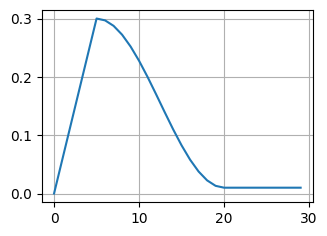

In [10]:
scheduler = CosineScheduler(20, warmup_steps=5, base_lr=0.3, final_lr=0.01)
plot(torch.arange(num_epochs), [scheduler(t) for t in range(num_epochs)])

### 练习11.11.5
可以试着把优化和采样联系起来吗？首先，在随机梯度朗之万动力学上使用 ([Welling.Teh.2011](https://zh.d2l.ai/chapter_references/zreferences.html#id181))的结果。

**解答：**

- **随机梯度下降（SGD）**：在优化神经网络中，随机梯度下降是一种常用的优化算法。它通过使用每个训练样本的随机梯度来更新模型的参数。SGD的主要思想是沿着梯度方向更新参数，以最小化损失函数。

- **朗之万动力学（Langevin Dynamics）**：朗之万动力学是一种物理学中的模型，用于描述粒子在势能场中的随机运动。将朗之万动力学引入优化中，可以通过在参数更新中添加随机扰动来模拟参数的随机变化。这种随机性可以帮助模型跳出局部极小值，并在优化过程中探索更广阔的参数空间。

结合SGD和朗之万动力学的特点，于是有了SGLD算法

**SGLD算法**：SGLD算法结合了随机梯度下降和朗之万动力学。它在每次参数更新时，使用随机梯度下降的步骤进行参数更新，并添加一个朗之万动力学的随机扰动项。这个随机扰动项是由高斯噪声和学习率控制的。通过这种方式，SGLD算法可以在优化过程中进行采样，从而估计参数的后验分布。